# <b><font color='saddlebrown'>Практикум</font></b>

#### <b><font color='saddlebrown'>Задачи на вероятности и теорему Байеса</font></b>

##### <b><font color='saddlebrown'>1. Конверсия и отток</font></b>
<i> Контекст:</i> Аналитик изучает поведение пользователей в приложении. Известно, что 20% пользователей совершают покупку (целевое действие). Также известно, что 15% от общего числа пользователей и покупают, и при этом обращались в чат поддержки. Всего в чат поддержки обращаются 30% пользователей <br>
<i> Вопрос: </i> Какова вероятность того, что пользователь совершит покупку, если мы знаем, что он уже обратился в поддержку?

In [1]:
# Общие импорты для всего практикума
import numpy as np
from scipy import stats

In [4]:
buy = 0.2
support_buy = 0.15
support = 0.3
# P(A|B) = P(A ∩ B) / P(B)
P = support_buy / support
print(f"P(A|B) = {P:.2f}")

P(A|B) = 0.50


##### <b><font color='saddlebrown'>2. Кредитный скоринг</font></b>
<i> Контекст:</i> Заявки на кредит приходят из трех каналов: сайт (50%), мобильное приложение (30%) и партнерская сеть (20%). Доля дефолтов (невозвратов) для каждого канала составляет: для сайта — 2%, для приложения — 1%, для партнеров — 5%. <br>
<i> Вопрос: </i> Какова средняя (полная) вероятность дефолта по всему портфелю новых заявок?

In [ ]:
site = 0.5  # P(A)
mobile = 0.3  # P(B)
partner = 0.2  # P(C)
d_site = 0.02  # P(D|A)
d_mobile = 0.01 # P(D|B)
d_partner = 0.05 # P(D|C)

# P(D) = P(D|A)P(A) + P(D|B)P(B) + P(D|C)P(C)
P_D = d_site * site + d_mobile * mobile + d_partner * partner

print(f"P(D) = {P_D * 100:.2f}%")



P(D) = 2.30%


##### <b><font color='saddlebrown'>3. Эффективность Push-уведомлений</font></b>
<i> Контекст:</i> Маркетологи разослали push-уведомление с акцией только 30% случайно выбранных пользователей приложения (остальные 70% составили контрольную группу и пуш не получили).<br>
В конце дня аналитик видит общую картину:
- Среди тех, кто получил пуш, покупку совершили 6% (конверсия тестовой группы).
- Среди тех, кто не получал пуш, покупку совершили 2% (базовая конверсия за счет органики).<br>
Вечером в логах зафиксирована покупка от пользователя. Мы не знаем из какого он лога, но видим факт транзакции. <br>
<i> Вопрос: </i> Какова вероятность того, что этот конкретный покупатель совершил покупку благодаря пушу (то есть находился в группе, получившей уведомление)?

In [11]:
push = 0.3 # P(A)
no_push = 0.7 # P(B|A) = 0.06, P(B|B) = 0.02
push_b = 0.06 # P(B|A)
no_push_b = 0.02 # P(B|B)
# P(B) = P(B|A)P(A) + P(B|B)P(B)
P_B = push_b * push + no_push_b * no_push
print(f"P(B) = {P_B * 100:.2f}%")
# Какова вероятность того, что этот конкретный покупатель совершил покупку благодаря пушу 
# (то есть находился в группе, получившей уведомление)?
# P(A|B) = P(B|A)P(A) / P(B)
P_A_given_B = (push_b * push) / P_B
print(f"P(A|B) = {P_A_given_B * 100:.2f}%")

P(B) = 3.20%
P(A|B) = 56.25%


#### <b><font color='saddlebrown'>Задачи на функции распределения (CDF, PPF, SF)</font></b>

##### <b><font color='saddlebrown'>1. Анализ LTV и чеков</font></b>
<b>LTV (Lifetime Value) </b> показывает, сколько денег в среднем приносит один клиент за всё время взаимодействия с бизнесом.<br>
<i>Контекст: </i> Средний чек покупателей в интернет-магазине распределен нормально со средним значением ($\mu$) 3000 рублей и стандартным отклонением ($\sigma$) 800 рублей.<br>
<i>Вопрос:</i> Какой процент покупателей совершает покупку на сумму менее 2000 рублей?<br>

In [13]:
mu = 3000
sigma = 800
# Какой пронецт покупателей совершает покупку на сумму менее 2000 р 
sales = 2000
# P(X < sales) = CDF((sales - mu) / sigma)
z_score = (sales - mu) / sigma
display(z_score)
probability = stats.norm.cdf(z_score)
print(f"Вероятность покупки на сумму менее {sales} р: {probability * 100:.2f}%")


-1.25

Вероятность покупки на сумму менее 2000 р: 10.56%


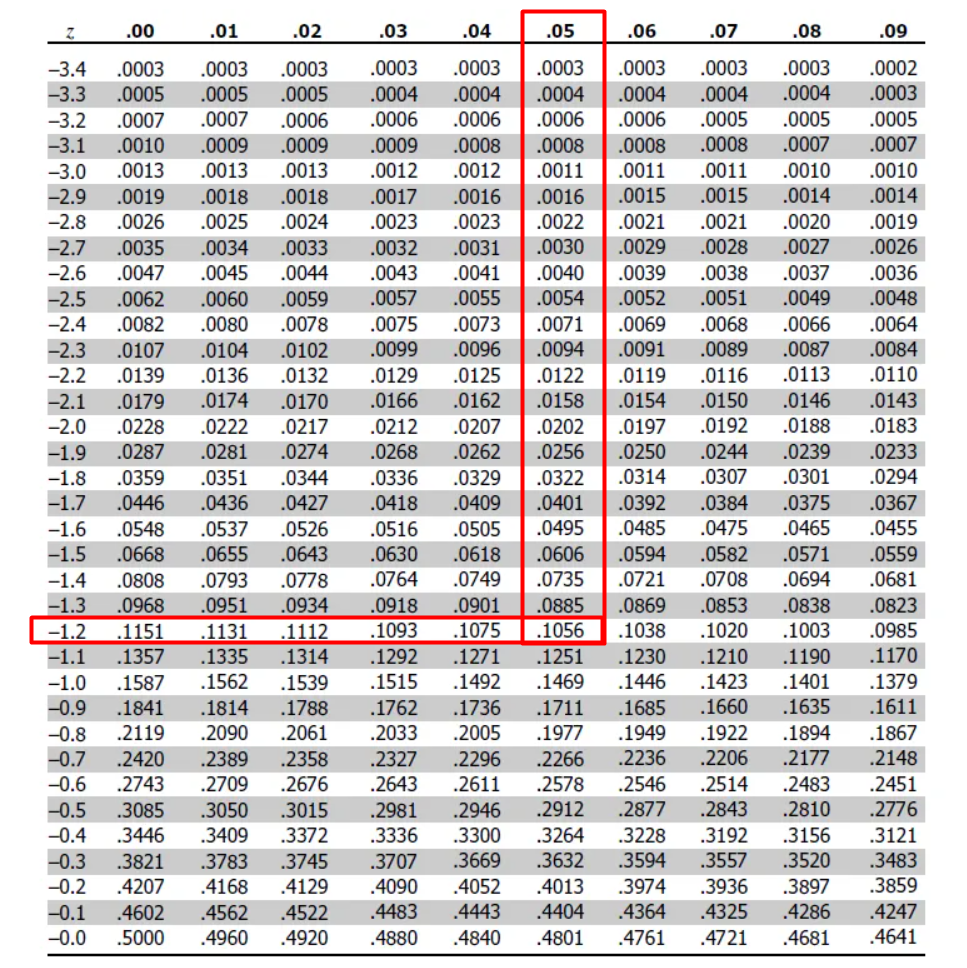

##### <b><font color='saddlebrown'>2. Удержание пользователей (Retention)</font></b>
<b>Retention </b> показывает, сколько людей продолжили пользоваться продуктом спустя определённое время после первого контакта.<br>
<i>Контекст: </i> Время, которое пользователи проводят на сайте перед тем, как закрыть вкладку, распределено нормально со средним 5 минут и стандартным отклонением 1.5 минуты.<br>
<i>Вопрос:</i> Какая доля пользователей остается на сайте дольше 7 минут?<br>

In [19]:
mu = 5
std = 1.5
# Какая доля пользователей остается на сайте дольше 7 минут?
time = 7
z_score = (time - mu) / std
display(f"z_score: {z_score}")
probability = 1 - stats.norm.cdf(z_score)
print(f"Доля пользователей, остающихся на сайте дольше {time} минут: {probability * 100:.2f}%")

'z_score: 1.3333333333333333'

Доля пользователей, остающихся на сайте дольше 7 минут: 9.12%


##### <b><font color='saddlebrown'>3. Программа лояльности</font></b>
<i>Контекст: </i> Маркетологи хотят запустить закрытый клуб для топ-5% клиентов по объемам покупок. Известно, что количество заказов на одного клиента в год распределено нормально со средним 40 заказов и стандартным отклонением 12.<br>
<i>Вопрос:</i> Какое минимальное количество заказов должен совершить клиент за год, чтобы попасть в эти топ-5%?<br>

In [ ]:
top_buy = 0.05
mu = 40
std = 12
# Какое минимальное количество заказов должен совершить клиент за год, чтобы попасть в эти топ-5%?
z_score = stats.norm.ppf(1 - top_buy)
display(f"z_score: {z_score}")
X = mu + z_score * std
print(f"Минимальное количество заказов для попадания в топ-5%: {X:.0f}")


'z_score: 1.6448536269514722'

Минимальное количество заказов для попадания в топ-5%: 60


#### <b><font color='saddlebrown'>Задачи на Z-score</font></b>

##### <b><font color='saddlebrown'>1. Data cleaning</font></b>
<i>Контекст: </i> У вас есть лог времени загрузки главной страницы сайта (в секундах). Нужно автоматически отфильтровать аномально долгие загрузки (технические сбои), используя правило (Z-score > 3).<br>
<i>Данные:</i> [1.2, 1.5, 1.1, 1.4, 1.3, 15.2, 1.2, 1.6, 1.3, 1.4]<br>

In [54]:
data = [1.2, 1.5, 1.1, 1.4, 1.3, 15.2, 1.2, 1.6, 1.3, 1.4]
# Вычисляем z-оценки для каждого элемента
z_scores = stats.zscore(data, ddof=0)
for i, z in enumerate(z_scores):
    print(f"Элемент: {data[i]}, z-оценка: {z:.4f}")
    if round(abs(z), 2) >= 3.00 or round(abs(z), 2) <= -3.00:
        print(f"Элемент {data[i]} является выбросом.")
    else:
        print('В рамках нормы')
    print('------------------------')

data.pop(z_scores.argmax())
print(f"Данные после удаления выброса: {data}")

import plotly.express as px
fig = px.box(data, title="Boxplot для выявления выбросов")
fig.show()


Элемент: 1.2, z-оценка: -0.3652
В рамках нормы
------------------------
Элемент: 1.5, z-оценка: -0.2931
В рамках нормы
------------------------
Элемент: 1.1, z-оценка: -0.3892
В рамках нормы
------------------------
Элемент: 1.4, z-оценка: -0.3171
В рамках нормы
------------------------
Элемент: 1.3, z-оценка: -0.3411
В рамках нормы
------------------------
Элемент: 15.2, z-оценка: 2.9983
Элемент 15.2 является выбросом.
------------------------
Элемент: 1.2, z-оценка: -0.3652
В рамках нормы
------------------------
Элемент: 1.6, z-оценка: -0.2691
В рамках нормы
------------------------
Элемент: 1.3, z-оценка: -0.3411
В рамках нормы
------------------------
Элемент: 1.4, z-оценка: -0.3171
В рамках нормы
------------------------
Данные после удаления выброса: [1.2, 1.5, 1.1, 1.4, 1.3, 1.2, 1.6, 1.3, 1.4]


##### <b><font color='saddlebrown'>2. KPI отдела продаж</font></b>
<i>Контекст: </i> Менеджер по продажам в среднем закрывает 15 сделок в месяц со стандартным отклонением 3. В текущем месяце один из сотрудников закрыл 22 сделки.<br>
<i>Данные:</i> Переведите этот результат в Z-score. Насколько этот результат выдающийся (какова вероятность случайно закрыть столько или больше сделок)?<br>

In [39]:
mu = 15 # Среднее количество сделок, которое обычно закрывает сотрудник в месяц
std = 3 # Стандартное отклонение количества сделок, закрываемых сотрудником в месяц
n = 22 # Количество сделок которое закрыл сотрудник в этом месяце

z_score = (n - mu) / std
# Насколько 22 это выдающийся результат и какова вероятность закртыть 22 сделки в месяц?
print(f"z_score: {z_score:.2f}")
probability = 1 - stats.norm.cdf(z_score)
print(f"Вероятность закрыть 22 сделки в месяц: {probability * 100:.2f}%")



z_score: 2.33
Вероятность закрыть 22 сделки в месяц: 0.98%


##### <b><font color='saddlebrown'>3. HR-аналитика</font></b>
<i>Контекст: </i> Вы выбираете лучшего сотрудника года среди разных отделов.
- Аналитик Иван из отдела внедрения закрыл KPI на 92 балла (в его отделе средний балл равен 80, стандартное отклонение 5).
- Разработчик Петр из отдела R&D закрыл KPI на 85 баллов (в его отделе средний балл равен 72, стандартное отклонение 4).<br>
<i>Данные:</i> Кто из сотрудников показал более выдающийся результат относительно своих коллег?<br>

In [45]:
ivan = 92
mu_ivan = 80
std_ivan = 5

petr = 85
mu_petr = 72
std_petr = 4

z_ivan = (ivan - mu_ivan) / std_ivan
z_petr = (petr - mu_petr) / std_petr

print(f"z_ivan: {z_ivan:.2f}")
print(f"z_petr: {z_petr:.2f}")

probability_ivan = 1 - stats.norm.cdf(z_ivan)
probability_petr = 1 - stats.norm.cdf(z_petr)
print(f"Вероятность для Ивана: {probability_ivan * 100:.2f}%")
print(f"Вероятность для Петра: {probability_petr * 100:.2f}%")

if probability_ivan < probability_petr:
    print("Иван показал более выдающийся результат.")
elif probability_petr < probability_ivan:
    print("Петр показал более выдающийся результат.")

z_ivan: 2.40
z_petr: 3.25
Вероятность для Ивана: 0.82%
Вероятность для Петра: 0.06%
Петр показал более выдающийся результат.
